<a href="https://colab.research.google.com/github/mahigarg0403-blip/Customer-purchase-prediction_mahi_bhumika/blob/main/notebooks/step9_shap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import shutil
import warnings
warnings.filterwarnings('ignore')

path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'

Mounted at /content/drive


In [2]:
# Load best model
rf_model = joblib.load(path + 'random_forest.pkl')

# Load test data (tree version since RF uses label encoding)
X_test = pd.read_csv(path + 'step 4/x_test_tree_final.csv')
y_test = pd.read_csv(path + 'step 4/y_test_tree_final.csv').values.ravel()
X_train = pd.read_csv(path + 'step 4/x_train_tree_final.csv')

print("Model loaded:", rf_model)
print("X_test shape:", X_test.shape)
print("X_train shape:", X_train.shape)

Model loaded: RandomForestClassifier(n_estimators=200, random_state=42)
X_test shape: (2441, 21)
X_train shape: (16476, 21)


In [3]:
explainer = shap.TreeExplainer(rf_model)
print("Explainer created successfully")

Explainer created successfully


In [5]:
explainer = shap.TreeExplainer(rf_model)
X_test_sample = X_test.sample(500, random_state=42).reset_index(drop=True)

shap_values = explainer.shap_values(X_test_sample)

print("Type:", type(shap_values))
print("Length:", len(shap_values))

if isinstance(shap_values, list):
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
    shap_vals_purchase = shap_values[1]
else:
    print("shap_values shape:", shap_values.shape)
    shap_vals_purchase = shap_values[:, :, 1]

print("Final SHAP values shape:", shap_vals_purchase.shape)

Type: <class 'numpy.ndarray'>
Length: 500
shap_values shape: (500, 21, 2)
Final SHAP values shape: (500, 21)


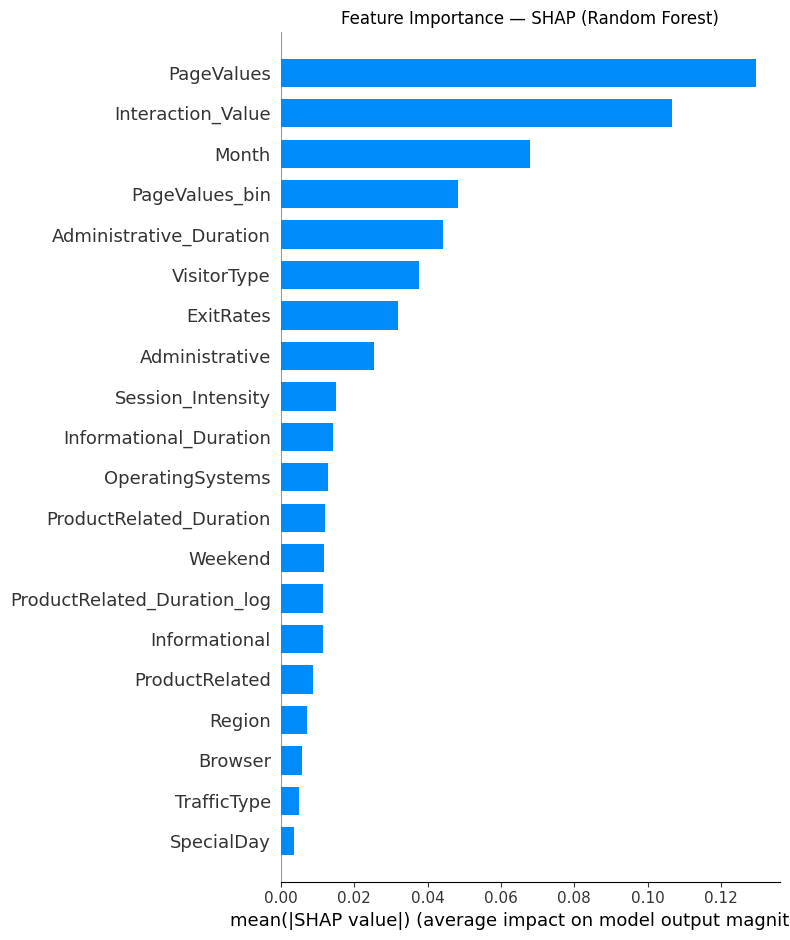

Summary bar plot saved ✅


In [6]:
plt.figure()
shap.summary_plot(
    shap_vals_purchase,
    X_test_sample,
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — SHAP (Random Forest)')
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary bar plot saved ✅")

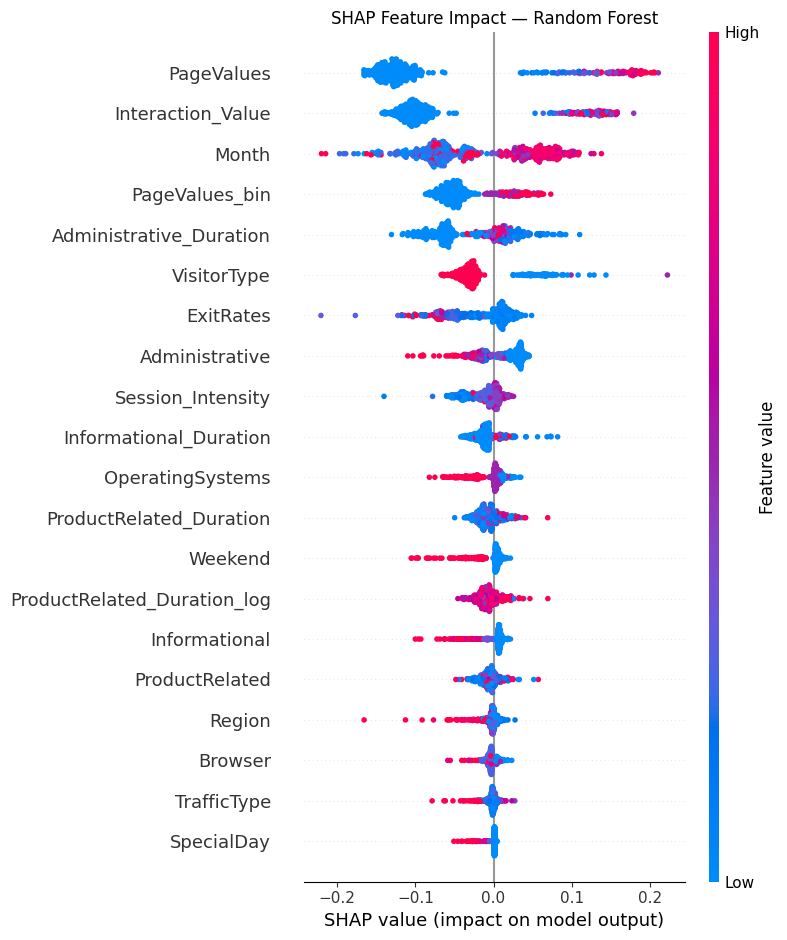

Summary dot plot saved ✅


In [7]:
plt.figure()
shap.summary_plot(
    shap_vals_purchase,
    X_test_sample,
    show=False
)
plt.title('SHAP Feature Impact — Random Forest')
plt.tight_layout()
plt.savefig('shap_summary_dot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary dot plot saved ✅")

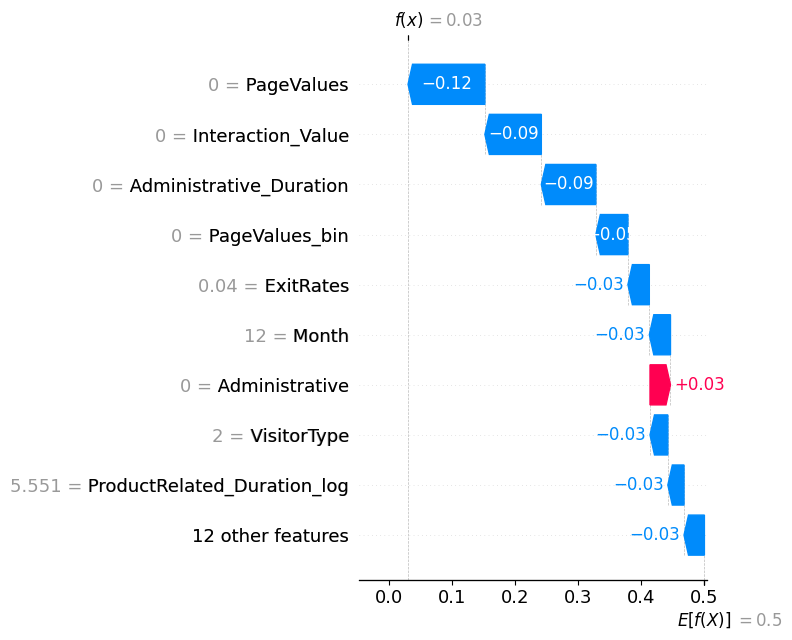

Waterfall plot saved ✅


In [8]:
explanation = shap.Explanation(
    values=shap_vals_purchase[0],
    base_values=explainer.expected_value[1],
    data=X_test_sample.iloc[0].values,
    feature_names=X_test_sample.columns.tolist()
)

shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved ✅")

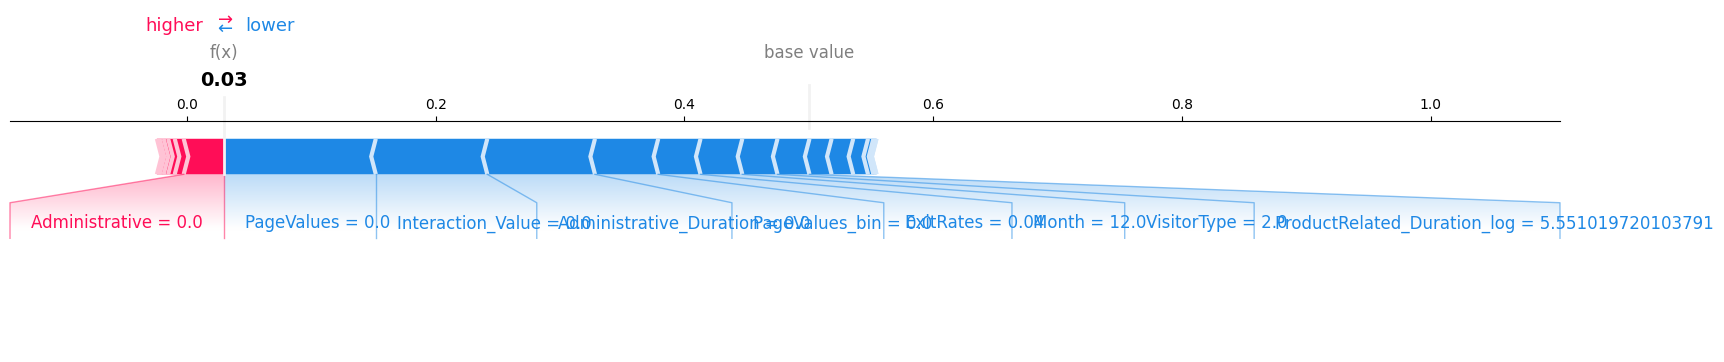

Force plot saved ✅


In [9]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_vals_purchase[0],
    X_test_sample.iloc[0],
    feature_names=X_test_sample.columns.tolist(),
    matplotlib=True,
    show=False
)

plt.savefig('shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Force plot saved ✅")

In [14]:
mean_shap = pd.DataFrame({
    'Feature': X_test_sample.columns,
    'Mean SHAP Value': np.abs(shap_vals_purchase).mean(axis=0)
}).sort_values('Mean SHAP Value', ascending=False)

print("Top 10 most important features by SHAP:")
print(mean_shap.head(10).to_string(index=False))

Top 10 most important features by SHAP:
                Feature  Mean SHAP Value
             PageValues         0.129570
      Interaction_Value         0.106638
                  Month         0.067989
         PageValues_bin         0.048303
Administrative_Duration         0.044088
            VisitorType         0.037717
              ExitRates         0.031915
         Administrative         0.025498
      Session_Intensity         0.014938
 Informational_Duration         0.014319


In [15]:
plots = ['shap_summary_bar.png',
         'shap_summary_dot.png',
         'shap_waterfall.png',
         'shap_force_plot.png']

for plot in plots:
    shutil.copy(plot, path + plot)
    print(f"Saved {plot} ✅")

Saved shap_summary_bar.png ✅
Saved shap_summary_dot.png ✅
Saved shap_waterfall.png ✅
Saved shap_force_plot.png ✅
